<a href="https://colab.research.google.com/github/akashvgeorge/exit_ex/blob/main/exit_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries


In [330]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler, LabelEncoder

# Loading data

In [331]:
df = pd.read_excel("/content/partpdf_1782718651214_partpdf_1772777095672_partpdf_1763620554909_eurovision_1998 to 2012.xlsx")

In [332]:
df.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [334]:
df.describe()

,Unnamed: 0,Year,Place,Points,Is.Final,Semi.Final.Number,Song.In.English,Song.Quality,Normalized.Points,energy,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
count,648.000000,648.000000,648.000000,648.000000,648.000000,281.000000,648.000000,648.000000,648.000000,482.000000,...,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,480.000000,304.000000
mean,324.500000,2006.543210,11.858025,77.783951,0.566358,1.327402,0.728395,2.636140,0.044753,0.725833,...,0.571246,113.905349,0.056576,5.782158,0.201399,3.900415,0.580913,-6.516718,0.521286,5.406843
std,187.205769,4.016733,6.795186,63.301464,0.495960,0.470103,0.445131,2.089733,0.034887,0.186675,...,0.136131,24.958535,0.050582,3.453922,0.172561,0.485164,0.493922,2.358372,0.236548,0.288879
min,1.000000,1998.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-0.424200,0.000000,0.064730,...,0.183719,64.971000,0.023994,0.000000,0.026513,1.000000,0.000000,-21.878000,0.017786,4.375630
25%,162.750000,2004.000000,6.000000,30.000000,0.000000,1.000000,0.000000,1.017664,0.017946,0.607444,...,0.489436,91.968500,0.032869,2.250000,0.090076,4.000000,0.000000,-7.735000,0.328387,5.251099
50%,324.500000,2007.000000,12.000000,62.000000,1.000000,1.000000,1.000000,2.054728,0.035151,0.759969,...,0.574584,121.357500,0.041742,6.000000,0.136240,4.000000,1.000000,-6.169500,0.525902,5.464790
75%,486.250000,2010.000000,17.000000,110.000000,1.000000,2.000000,1.000000,3.864811,0.065451,0.881004,...,0.669654,130.163000,0.060256,9.000000,0.277933,4.000000,1.000000,-4.894000,0.723856,5.579380
max,648.000000,2012.000000,28.000000,387.000000,1.000000,2.000000,1.000000,9.795199,0.158867,0.999169,...,0.894179,211.985000,0.505107,11.000000,0.987510,7.000000,1.000000,-2.352000,0.971989,6.148232


# Handling Null Values

In [335]:
df.duplicated().sum()

np.int64(0)

In [336]:
df.isna().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,422
Group.Solo,422
Place,0
Points,0


In [337]:
missing_percent = df.isna().sum()/len(df)*100
sorted = missing_percent.sort_values(ascending=True)
sorted

,0
Unnamed: 0,0.000000
Year,0.000000
Country,0.000000
Region,0.000000
Artist,0.000000
Song,0.000000
Points,0.000000
Place,0.000000
Is.Final,0.000000
Song.In.English,0.000000


In [338]:
df = df.drop(columns=["Unnamed: 0"])

In [339]:
high_missing_cols = [c for c in ["Artist.gender", "Group.Solo"] if c in df.columns]
df = df.drop(columns=high_missing_cols, errors="ignore")

Since these columns(Artist.gender, Group.solo) have high values, these columns are dropped

In [340]:
audio_cols = [
    "energy","duration","mode","time_signature","loudness","danceability",
    "speechiness","tempo","key","liveness","valence","acousticness"
]

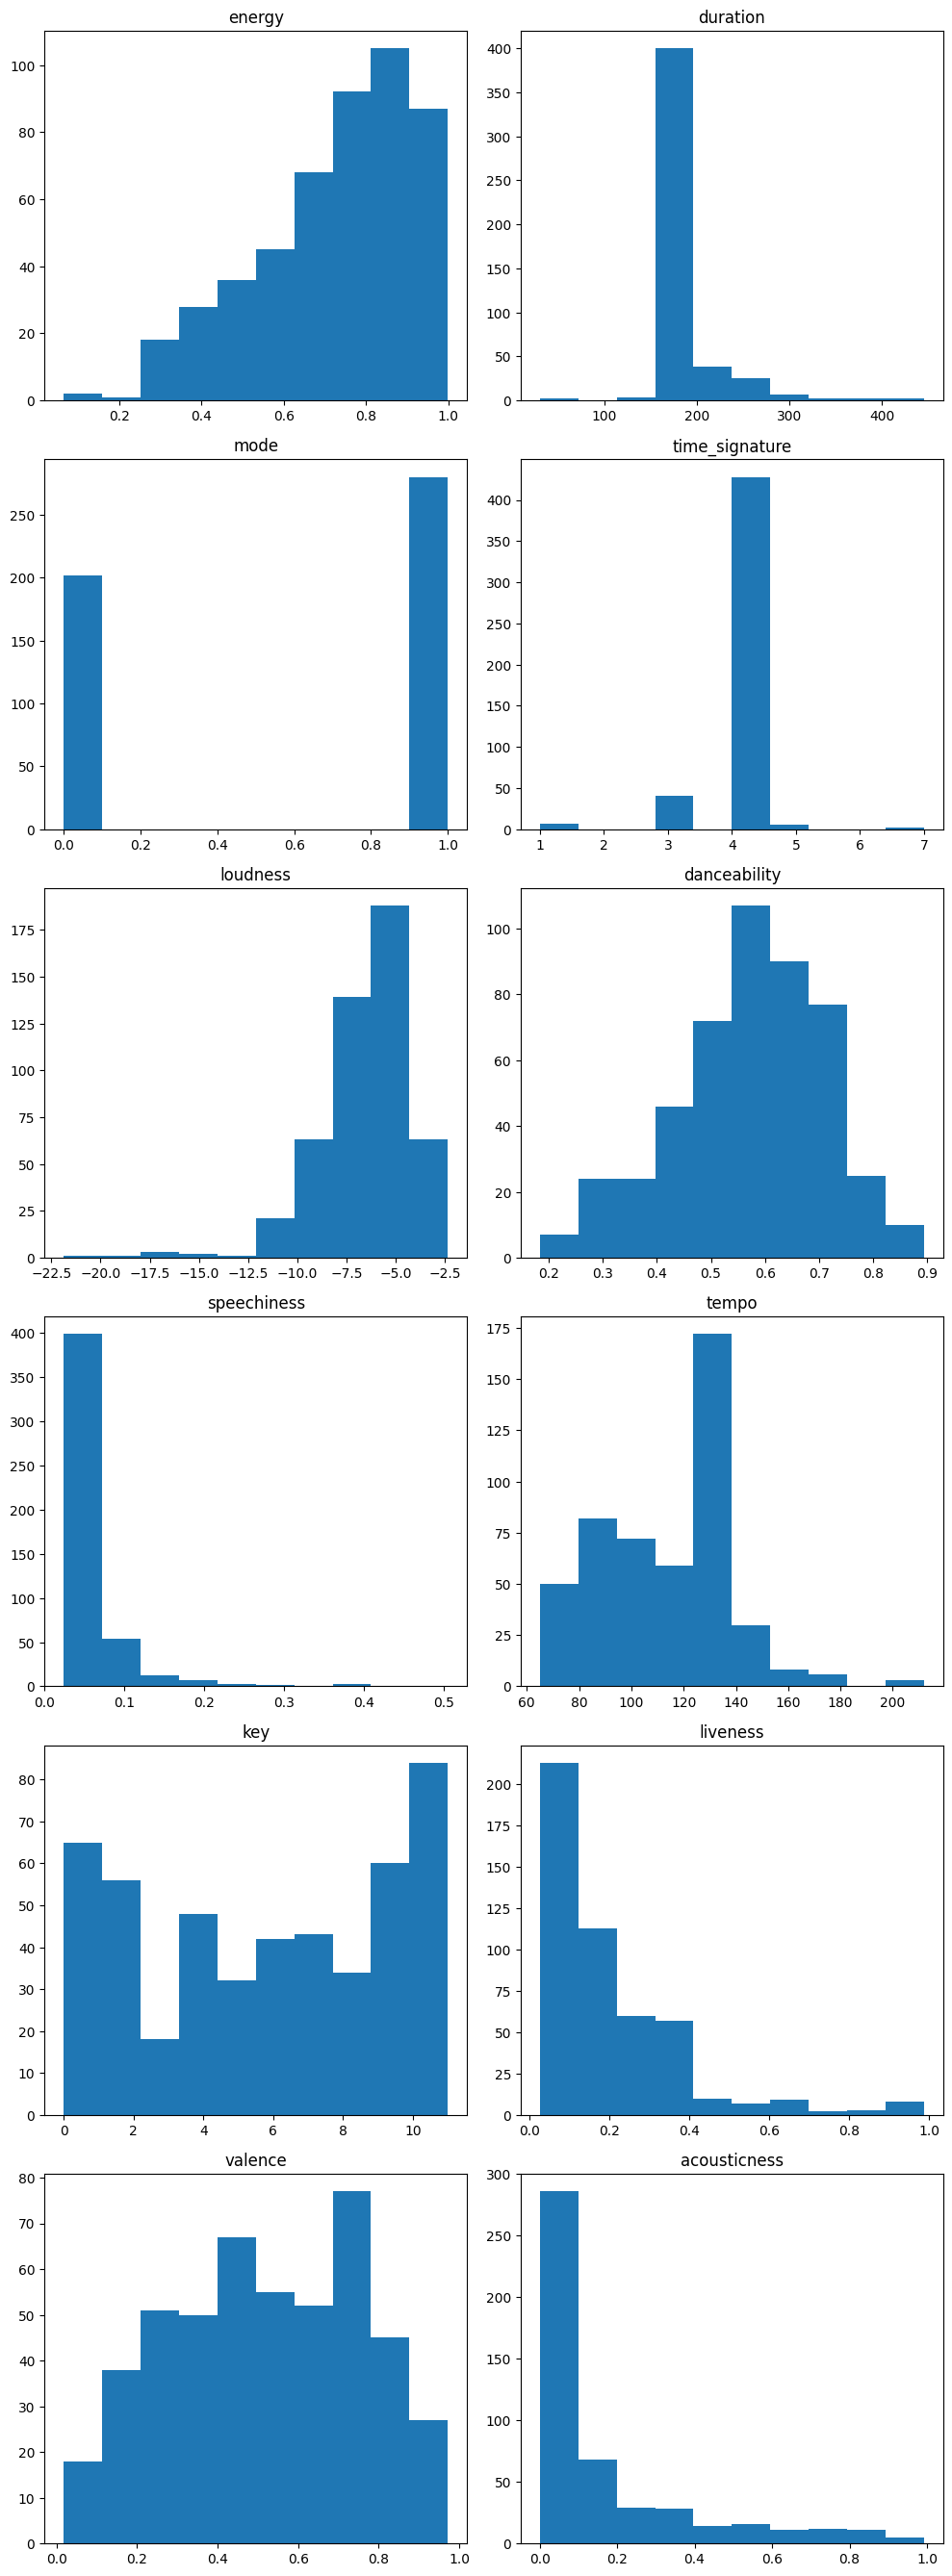

In [341]:
plt.figure(figsize = (10, 40))
for i, col in enumerate(audio_cols,1):
  plt.subplot(9,2,i)
  plt.hist(df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [342]:
audio_cols = [c for c in audio_cols if c in df.columns]
for c in audio_cols:
    df[c] = df[c].fillna(df[c].median())


 audio features (25% missing): median imputation
 From the graph, each columns shows a skewed distribution and hence used median to fill the missing values

Additionally Happiness and Semi.Final.Number have high percentage of missing values, they can also be dropped

In [343]:
missing_cols = ["Semi.Final.Number", "Happiness"]

In [344]:
df = df.drop(columns=missing_cols, errors="ignore")

In [345]:
df.isna().sum()

,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Place,0
Points,0
Home.Away.Country,0
Home.Away.Region,0
Is.Final,0


# Correlation

In [346]:
num_cols = df.select_dtypes(include=['number']).columns


In [347]:
corr_matrix = df[num_cols].corr(method='pearson')
corr_matrix

,Year,Place,Points,Is.Final,Song.In.English,Song.Quality,Normalized.Points,energy,duration,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence
Year,1.000000,-0.080978,0.095156,-0.415356,0.136240,0.071063,0.079929,-0.076745,-0.071535,0.104085,-0.050615,0.006750,0.058368,0.050241,0.051383,-0.032869,-0.144659,0.035170,-0.037367
Place,-0.080978,1.000000,-0.833308,0.141301,-0.085328,-0.901080,-0.909040,-0.040663,-0.053739,-0.027732,0.006653,0.023752,0.003240,-0.016406,-0.030394,-0.016124,0.116447,-0.016242,-0.003425
Points,0.095156,-0.833308,1.000000,0.045257,0.097306,0.876929,0.890372,0.032260,0.096076,0.045492,-0.031370,-0.056530,-0.000441,0.000298,0.031226,0.010022,-0.132662,0.015622,-0.008895
Is.Final,-0.415356,0.141301,0.045257,1.000000,-0.009248,-0.138282,-0.127235,-0.033710,0.038877,0.002839,0.020407,-0.020077,-0.098286,-0.017291,-0.003811,-0.006038,0.063223,-0.093027,0.000080
Song.In.English,0.136240,-0.085328,0.097306,-0.009248,1.000000,0.087816,0.094358,0.112574,-0.022468,-0.142467,0.140958,0.029265,-0.015036,0.009884,-0.069249,-0.016818,-0.081377,0.039793,0.139452
Song.Quality,0.071063,-0.901080,0.876929,-0.138282,0.087816,1.000000,0.992346,0.040735,0.075246,0.038308,-0.020101,-0.047090,-0.018226,-0.003319,-0.000872,0.016860,-0.112421,0.014851,-0.007857
Normalized.Points,0.079929,-0.909040,0.890372,-0.127235,0.094358,0.992346,1.000000,0.030949,0.075961,0.044532,-0.020131,-0.046927,-0.021154,-0.002651,0.001469,0.017184,-0.118779,0.011006,-0.011057
energy,-0.076745,-0.040663,0.032260,-0.033710,0.112574,0.040735,0.030949,1.000000,0.064210,-0.540968,0.345549,0.336186,0.195315,0.067421,0.134875,0.033661,-0.099542,0.571978,0.542007
duration,-0.071535,-0.053739,0.096076,0.038877,-0.022468,0.075246,0.075961,0.064210,1.000000,0.014618,-0.006372,0.059276,0.175323,-0.007672,0.047934,-0.035936,-0.114054,-0.065744,-0.014631
acousticness,0.104085,-0.027732,0.045492,0.002839,-0.142467,0.038308,0.044532,-0.540968,0.014618,1.000000,-0.272036,-0.156552,0.007353,-0.023422,-0.027004,-0.078374,-0.054238,-0.266395,-0.345241


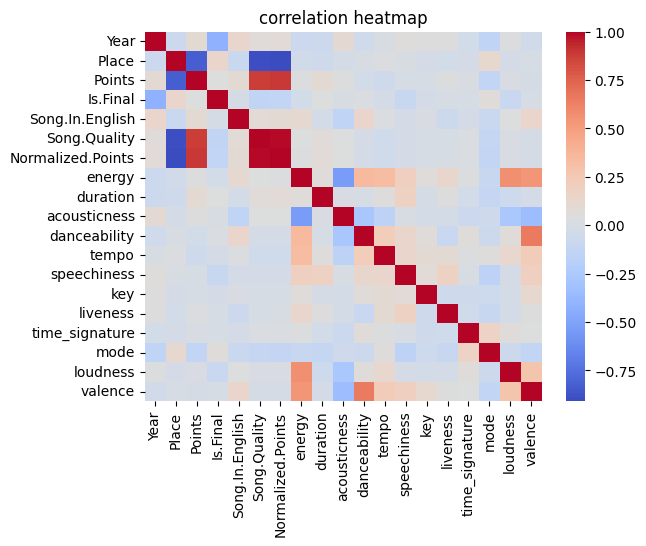

In [348]:
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [349]:
cols_to_drop = ['Song.Quality', 'Normalized.Points', 'key', 'time_signature', 'mode']
df = df.drop(columns=cols_to_drop, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               648 non-null    int64  
 1   Country            648 non-null    object 
 2   Region             648 non-null    object 
 3   Artist             648 non-null    object 
 4   Song               648 non-null    object 
 5   Place              648 non-null    int64  
 6   Points             648 non-null    int64  
 7   Home.Away.Country  648 non-null    object 
 8   Home.Away.Region   648 non-null    object 
 9   Is.Final           648 non-null    int64  
 10  Song.In.English    648 non-null    int64  
 11  energy             648 non-null    float64
 12  duration           648 non-null    float64
 13  acousticness       648 non-null    float64
 14  danceability       648 non-null    float64
 15  tempo              648 non-null    float64
 16  speechiness        648 non

Decided to remove the columns 'Song.Quality', 'Normalized.Points', 'key', 'time_signature', 'mode' due to low correlation with other columns

# EDA

In [350]:
num_cols

Index(['Year', 'Place', 'Points', 'Is.Final', 'Song.In.English',
       'Song.Quality', 'Normalized.Points', 'energy', 'duration',
       'acousticness', 'danceability', 'tempo', 'speechiness', 'key',
       'liveness', 'time_signature', 'mode', 'loudness', 'valence'],
      dtype='object')

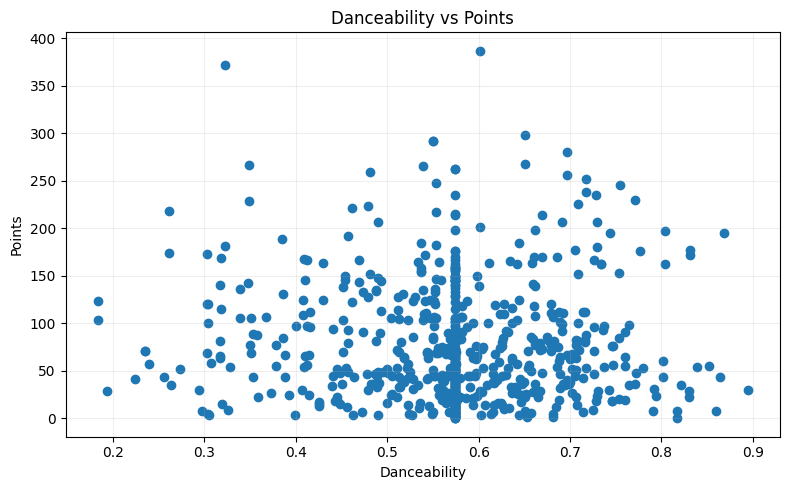

In [351]:
plot_df = df[["danceability", "Points"]]

plt.figure(figsize=(8, 5))
plt.scatter(
    data=plot_df,
    x="danceability",
    y="Points",
)
plt.title("Danceability vs Points")
plt.xlabel("Danceability")
plt.ylabel("Points")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

There is no significant linear correlation between a song's danceability and the points it receives in the Eurovision Song Contest. Other factors are likely more influential in determining a song's success.


In [352]:
cat_cols = df.select_dtypes(include=['object']).columns


In [353]:
cat_cols

Index(['Country', 'Region', 'Artist', 'Song', 'Home.Away.Country',
       'Home.Away.Region'],
      dtype='object')

In [354]:
df.head()

,Year,Country,Region,Artist,Song,Place,Points,Home.Away.Country,Home.Away.Region,Is.Final,Song.In.English,energy,duration,acousticness,danceability,tempo,speechiness,liveness,loudness,valence
0,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,23,23,Away,Home,1,1,0.678258,183.18476,0.563170,0.598360,102.984,0.027817,0.078643,-9.082,0.482059
1,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,16,53,Away,Away,1,1,0.794093,179.87873,0.068711,0.604542,105.972,0.024996,0.084805,-6.059,0.426209
2,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,8,107,Away,Away,1,0,0.574628,227.97333,0.654078,0.367344,124.005,0.043751,0.923905,-8.655,0.292870
3,2009,Sweden,Scandinavia,Malena Ernman,La voix,21,33,Away,Away,1,1,0.672746,178.45660,0.119194,0.513202,128.021,0.034855,0.143708,-4.536,0.206493
4,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,18,45,Away,Away,1,0,0.733959,182.83057,0.323643,0.590592,116.107,0.032406,0.079322,-4.427,0.344541


In [355]:
df.columns.tolist()

['Year',
 'Country',
 'Region',
 'Artist',
 'Song',
 'Place',
 'Points',
 'Home.Away.Country',
 'Home.Away.Region',
 'Is.Final',
 'Song.In.English',
 'energy',
 'duration',
 'acousticness',
 'danceability',
 'tempo',
 'speechiness',
 'liveness',
 'loudness',
 'valence']

In [356]:
num_cols = num_cols.drop(['Song.Quality', 'Normalized.Points', 'key', 'time_signature', 'mode'])

In [357]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3-Q1


upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((df[num_cols] > upper_limit) | (df[num_cols] < lower_limit)).any(axis=1)

outliers_df = df[outliers]

outlier_percentage = len(outliers_df) * 100/ len(df)

print("percentage fo outliers in the dataframe :", outlier_percentage)

percentage fo outliers in the dataframe : 49.382716049382715


In [358]:
outlier_counts = ((df[num_cols] > upper_limit) |
                  (df[num_cols] < lower_limit)).mean()*100

print(outlier_counts.sort_values(ascending=False))

duration           20.216049
acousticness       15.123457
speechiness        12.808642
loudness           10.030864
danceability        8.641975
liveness            8.487654
energy              5.092593
Points              2.932099
tempo               1.234568
valence             0.308642
Song.In.English     0.000000
Is.Final            0.000000
Year                0.000000
Place               0.000000
dtype: float64


In [359]:
clip_cols = ['duration', 'acousticness', 'speechiness', 'loudness', 'danceability', 'liveness']
df[clip_cols] = df[clip_cols].clip(lower_limit, upper_limit, axis=1)

# Model Training and Evaluation

In [360]:
y = df['Points']

X = df.drop(columns=['Points', 'Artist', 'Song', 'Country', 'Region', 'Home.Away.Country', 'Home.Away.Region'])

X = pd.get_dummies(X, columns=['Year', 'Is.Final', 'Song.In.English'], drop_first=True, dtype=int)

X.head()

,Place,energy,duration,acousticness,danceability,tempo,speechiness,liveness,loudness,valence,...,Year_2005,Year_2006,Year_2007,Year_2008,Year_2009,Year_2010,Year_2011,Year_2012,Is.Final_1,Song.In.English_1
0,23,0.678258,183.184760,0.295968,0.598360,102.984,0.027817,0.078643,-9.082,0.482059,...,0,0,0,0,1,0,0,0,1,1
1,16,0.794093,179.878730,0.068711,0.604542,105.972,0.024996,0.084805,-6.059,0.426209,...,0,0,0,0,1,0,0,0,1,1
2,8,0.574628,189.667661,0.295968,0.367344,124.005,0.043751,0.355778,-8.655,0.292870,...,0,0,0,0,1,0,0,0,1,0
3,21,0.672746,178.456600,0.119194,0.513202,128.021,0.034855,0.143708,-4.536,0.206493,...,0,0,0,0,1,0,0,0,1,1
4,18,0.733959,182.830570,0.295968,0.590592,116.107,0.032406,0.079322,-4.427,0.344541,...,0,0,0,0,1,0,0,0,1,0


In [362]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [363]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    shuffle=True
)

In [364]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    verbosity=0,
    random_state=42,
    reg_lambda=1.5,
    early_stopping_rounds=10
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

y_train_pred = xgb_model.predict(X_tr)
y_val_pred   = xgb_model.predict(X_val)
y_test_pred  = xgb_model.predict(X_test)

In [365]:
print("Training")
print(f"MAE      : {mean_absolute_error(y_tr, y_train_pred):.4f}\n")

print("Validation")
print(f"MAE      : {mean_absolute_error(y_val, y_val_pred):.4f}\n")

print("Testing")
print(f"MAE      : {mean_absolute_error(y_test, y_test_pred):.4f}")


Training
MAE      : 3.4416

Validation
MAE      : 18.0535

Testing
MAE      : 17.6981


In [366]:
RANDOM_STATE = 42

n_estimators_list = [10, 50, 100, 200, 500]
max_depth_list = [2, 4, 8, 16, 32, 64, None]
min_samples_split_list = [2, 10, 30, 50, 100, 200]

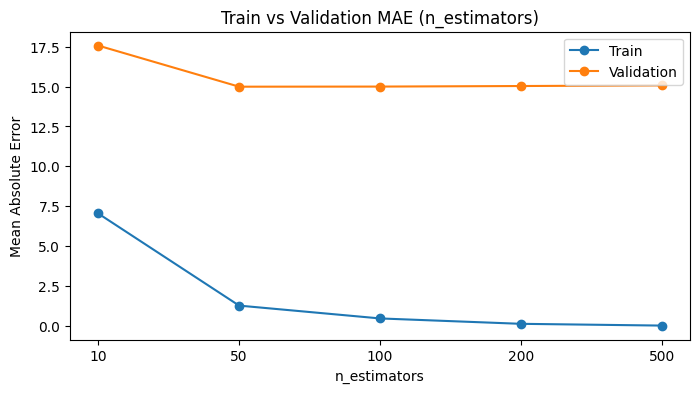

In [367]:
mae_list_train = []
mae_list_val = []

for n_estimators in n_estimators_list:
  model = XGBRegressor(n_estimators=n_estimators, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_test)

  mae_list_train.append(mean_absolute_error(y_train, predictions_train))
  mae_list_val.append(mean_absolute_error(y_test, predictions_val))

plt.figure(figsize=(8,4))
plt.title('Train vs Validation MAE (n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('Mean Absolute Error')
plt.xticks(ticks=range(len(n_estimators_list)), labels=n_estimators_list)
plt.plot(mae_list_train, marker='o', label='Train')
plt.plot(mae_list_val, marker='o', label='Validation')
plt.legend()
plt.show()

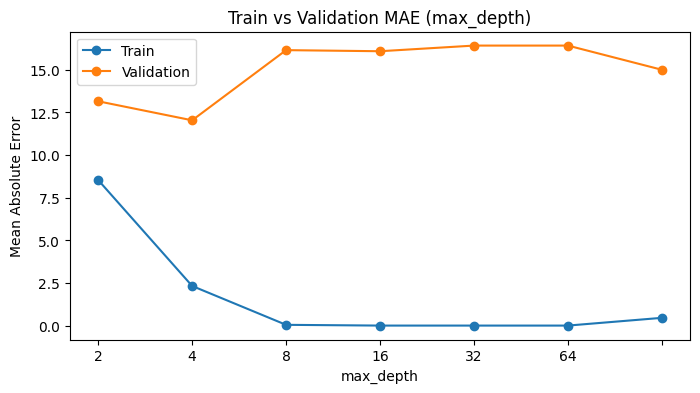

In [368]:
mae_list_train = []
mae_list_val = []

for max_depth in max_depth_list:
  model = XGBRegressor(max_depth=max_depth, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_test)

  mae_list_train.append(mean_absolute_error(y_train, predictions_train))
  mae_list_val.append(mean_absolute_error(y_test, predictions_val))

plt.figure(figsize=(8,4))
plt.title('Train vs Validation MAE (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('Mean Absolute Error')
plt.xticks(ticks=range(len(max_depth_list)), labels=max_depth_list)
plt.plot(mae_list_train, marker='o', label='Train')
plt.plot(mae_list_val, marker='o', label='Validation')
plt.legend()
plt.show()

In [369]:
N_estimators = 200
Max_depth = 5

In [381]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.02,
    max_depth=5,
    min_child_weight=8,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=5.0,
    eval_metric='mae',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

y_train_pred = xgb_model.predict(X_tr)
y_val_pred   = xgb_model.predict(X_val)
y_test_pred  = xgb_model.predict(X_test)

In [382]:
print("Training")
print(f"MAE      : {mean_absolute_error(y_tr, y_train_pred):.4f}\n")

print("Validation")
print(f"MAE      : {mean_absolute_error(y_val, y_val_pred):.4f}\n")

print("Testing")
print(f"MAE      : {mean_absolute_error(y_test, y_test_pred):.4f}")


Training
MAE      : 12.8645

Validation
MAE      : 17.9157

Testing
MAE      : 18.5013


model is off by about 18 points per song on unseen data (test MAE  18.5).
In Eurovision terms (0–400 scale), that is about 4.6% error, which is fairly reasonable.
Since training MAE (12.9) is lower than validation/test (~18), there is some overfitting, but generalization is still acceptable.

In [376]:
print("Train target stats:")
print(y_train.describe())
print("\nTest target stats:")
print(y_test.describe())

Train target stats:
count    518.000000
mean      75.623552
std       63.010386
min        0.000000
25%       28.000000
50%       58.500000
75%      106.000000
max      387.000000
Name: Points, dtype: float64

Test target stats:
count    130.000000
mean      86.392308
std       63.969287
min        3.000000
25%       39.250000
50%       68.500000
75%      124.000000
max      292.000000
Name: Points, dtype: float64


In [386]:
import joblib

feature_columns = df.drop(columns=['Points', 'Artist', 'Song', 'Country', 'Region', 'Home.Away.Country', 'Home.Away.Region', 'Place']).columns.tolist()

dummy_cols = pd.get_dummies(df[['Year', 'Is.Final', 'Song.In.English']], columns=['Year', 'Is.Final', 'Song.In.English'], drop_first=True).columns.tolist()
feature_names = feature_columns + dummy_cols

joblib.dump(xgb_model, 'eurovision_xgb_model.joblib')
joblib.dump(feature_names, 'feature_columns.joblib')

print('Successfully saved: eurovision_xgb_model.joblib and feature_columns.joblib')

Successfully saved: eurovision_xgb_model.joblib and feature_columns.joblib


FileNotFoundError: [Errno 2] No such file or directory: 'Voting Final.csv'

❌ Voting Final.csv NOT found.
Please upload the file to the /content/ directory using the file explorer on the left.

Available files: ['.config', 'eurovision_xgb_model.joblib', 'partpdf_1782718651214_partpdf_1772777095672_partpdf_1763620554909_eurovision_1998 to 2012.xlsx', 'feature_columns.joblib', 'sample_data']


In [ ]:
import os

# 2. Create the Historical Template
os.makedirs('templates', exist_ok=True)

html_historical = """\
<!DOCTYPE html>
<html>
<head>
    <title>Eurovision Historical Ties</title>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 40px; text-align: center; background: #f8f9fa; }
        .card { background: white; padding: 30px; border-radius: 12px; display: inline-block; box-shadow: 0 4px 15px rgba(0,0,0,0.1); width: 400px; }
        select { padding: 12px; width: 100%; border-radius: 6px; border: 1px solid #ddd; margin-bottom: 20px; font-size: 16px; }
        #result { margin-top: 25px; padding: 15px; font-size: 18px; color: #2c3e50; border-top: 1px solid #eee; }
        .highlight { color: #5c67f2; font-weight: bold; }
        .back-link { display: block; margin-top: 20px; color: #888; text-decoration: none; }
    </style>
</head>
<body>
    <div class='card'>
        <h2>Who gives the most?</h2>
        <p>Select a country to find their historical 'Best Friend':</p>
        <select id='countrySelect' onchange='fetchProvider()'>
            <option value=''>-- Select a Country --</option>
        </select>
        <div id='result'>Selection a country to see stats...</div>
        <a href='/' class='back-link'>← Back to Predictor</a>
    </div>

    <script>
        // Fill dropdown on load
        fetch('/api/countries').then(r => r.json()).then(list => {
            const sel = document.getElementById('countrySelect');
            list.forEach(c => {
                let opt = document.createElement('option');
                opt.value = opt.text = c;
                sel.add(opt);
            });
        });

        async function fetchProvider() {
            const country = document.getElementById('countrySelect').value;
            const resDiv = document.getElementById('result');
            if (!country) return;

            const response = await fetch(`/api/top-provider?country=${country}`);
            const data = await response.json();

            if (data.provider) {
                resDiv.innerHTML = `<span class='highlight'>${data.provider}</span> is the biggest supporter, giving <span class='highlight'>${data.points}</span> points total!`;
            } else {
                resDiv.innerText = "No data found.";
            }
        }
    </script>
</body>
</html>
"""

with open('templates/historical.html', 'w') as f:
    f.write(html_historical)

print("templates/historical.html has been created.")

In [ ]:
flask_snippets = """\
# PASTE THESE INTO YOUR app.py

@app.route('/historical')
def historical_page():
    return render_template('historical.html')

@app.route('/api/countries')
def get_countries_list():
    df_hist = pd.read_csv('top_providers.csv')
    return jsonify(sorted(df_hist['To Country'].unique().tolist()))

@app.route('/api/top-provider')
def get_provider_data():
    target = request.args.get('country')
    df_hist = pd.read_csv('top_providers.csv')
    match = df_hist[df_hist['To Country'] == target]
    if not match.empty:
        return jsonify({
            'provider': match.iloc[0]['From Country'],
            'points': int(match.iloc[0]['Points'])
        })
    return jsonify({'error': 'Not found'}), 404
"""
print(flask_snippets)

### Instructions for VS Code Setup

To see your historical voting feature, ensure your folder looks like this:

```text
/eurovision_app
├── app.py
├── top_providers.csv
├── eurovision_xgb_model.joblib
├── feature_columns.joblib
└── templates/
    ├── index.html
    └── historical.html
```

Run your app by opening a terminal in VS Code and typing:
`python app.py`

Then visit `http://127.0.0.1:5000/historical` in your browser.